## Power Law + Gaussian Peak

In [1]:
import ler.gw_source_population.prior_functions as pf
import numpy as np
import matplotlib.pyplot as plt

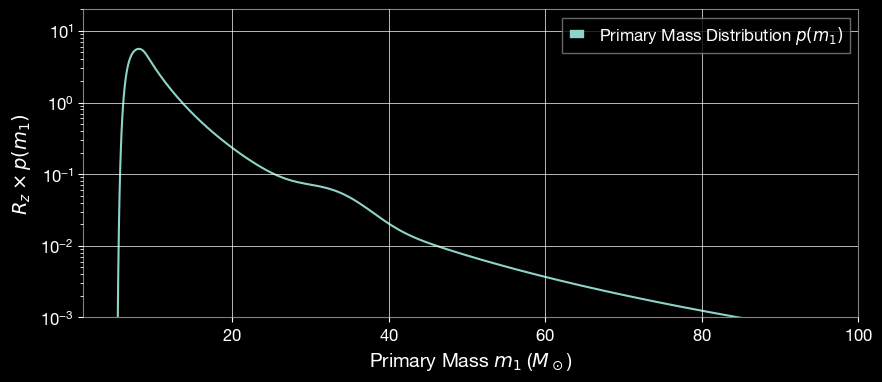

In [2]:
mlow_1 = 5.059
m1_arr = np.geomspace(mlow_1, 100.0, 200)
fn_m1 = pf.powerlaw_plus_peak_function(m1_arr)

plt.figure(figsize=(10, 4))
plt.plot(m1_arr, fn_m1, label='Primary Mass Distribution $p(m_1)$', color='C0')
plt.xlabel('Primary Mass $m_1$ ($M_\\odot$)', fontsize=14)
plt.ylabel('$R_z \\times p(m_1)$', fontsize=14)
plt.yscale('log')
plt.ylim(1e-3, 40)
plt.xlim(1, 100)
plt.legend()
plt.show()

## With FunctionConditioning

In [1]:
# disable numba njit completely for now since it is causing issues with the notebook
# import os
# os.environ["NUMBA_DISABLE_JIT"] = "1"  # set before importing numba

# import numba
# numba.config.DISABLE_JIT = 1

import ler.gw_source_population.prior_functions as pf
from ler.utils import FunctionConditioning
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [8]:
param_dict_m1 = dict(mminbh=4.98, mmaxbh=112.5, alpha=3.78, mu_g=32.27, sigma_g=3.88, lambda_peak=0.003, delta_m=4.8, beta=0.81)
normalization_size=200
# create list using the values
param_list = list(param_dict_m1.values())

mlow_1=param_dict_m1['mminbh']
mmax=param_dict_m1['mmaxbh']
m1_arr = np.geomspace(mlow_1, mmax, 100)
m1_fn = pf.powerlaw_plus_peak_function(m=m1_arr, mminbh=mlow_1, mmaxbh=mmax, alpha=param_dict_m1['alpha'], mu_g=param_dict_m1['mu_g'], sigma_g=param_dict_m1['sigma_g'], lambda_peak=param_dict_m1['lambda_peak'], delta_m=param_dict_m1['delta_m'], normalization_size=normalization_size)

m1_object = FunctionConditioning(
    function=m1_fn,  # can also be an array of function values
    x_array=m1_arr,
    non_negative_function=True,
    identifier_dict={},
    directory="./interpolator_json",
    sub_directory="default",
    name="default",
    create_new=True,
    create_function=True,
    create_pdf=True,
    create_rvs=True,
    callback='rvs',
)

param_dict_q = dict(beta=0.81, mminbh=4.98-0.01, delta_m=4.8)
param_list = list(param_dict_q.values())
size1 = 200
size2 = 100
m1_arr = np.geomspace(mlow_1, mmax, size1)
q_arr = np.linspace(param_dict_q['mminbh']/m1_arr, 1.0, size2).T
# q_arr.T, q_arr.T.shape

pdf_q_arr2d = []
for i, m1 in enumerate(m1_arr):
    m1_ = np.ones(size2) * m1
    q_ = q_arr[i]
    pdf_q = pf.mass_ratio_powerlaw_pdf(q_, m1_, beta=param_dict_q['beta'], mminbh=param_dict_q['mminbh'], delta_m=param_dict_q['delta_m'], normalization_size=normalization_size)
    pdf_q_arr2d.append(pdf_q)
    
pdf_q_arr2d = np.array(pdf_q_arr2d)

q_object = FunctionConditioning(
    function=pdf_q_arr2d,  # can also be an array of function values
    x_array=q_arr,
    conditioned_y_array=m1_arr,  # if this is not none, 2D interpolation will be used
    non_negative_function=True,
    identifier_dict={},
    directory="./interpolator_json",
    sub_directory="default",
    name="default",
    create_new=True,
    create_function=False,
    create_pdf=True,
    create_rvs=True,
    callback='rvs',
)

m1_object_pdf = m1_object.pdf
q_object_pdf = q_object.pdf
m1_object_rvs = m1_object.rvs
q_object_rvs = q_object.rvs

@njit
def m1m2_pdf(m1, m2):
    m1_pdf = m1_object_pdf(m1)
    m2_pdf = q_object_pdf(m2/m1, m1)

    return m1_pdf * m2_pdf

@njit
def m1m2_rvs(size):
    m1_samples = m1_object_rvs(size)
    q_samples = q_object_rvs(size, m1_samples)
    m2_samples = m1_samples * q_samples

    return m1_samples, m2_samples

m1m2_object = FunctionConditioning(
    non_negative_function=True,
    identifier_dict={},
    directory="./interpolator_json",
    sub_directory="default",
    name="default",
    create_new=True,
    create_function=m1_object.function,  # can also be an array of function values
    create_function_inverse=False,
    create_pdf=m1m2_pdf,
    create_rvs=m1m2_rvs,
    callback='rvs',
)
# spline: size= (100,50), time: 8.4s
# linear: size= (200,100), time: 5.7s

default interpolator will be generated at ./interpolator_json/default/default_0.json
default interpolator will be generated at ./interpolator_json/default/default_0.json


In [9]:
# samples
m1, m2 = m1m2_object.rvs(100000)
# spline, n=100000, time: 9.1s 
# linear, n=100000, time: 0.5s 

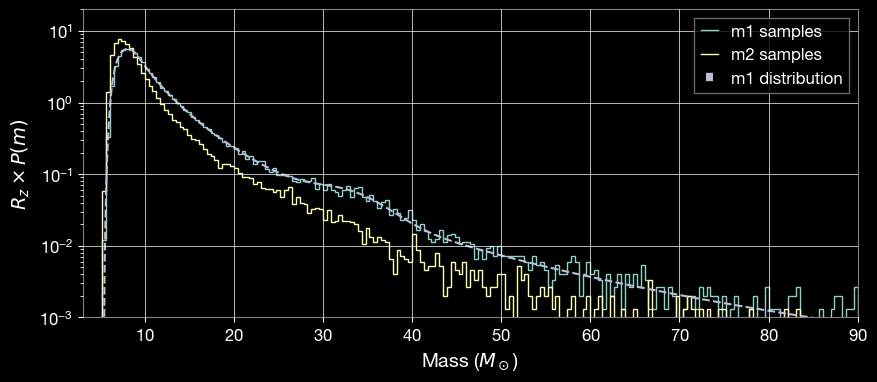

In [10]:
# rate
R0=16.158
kappa=3.166 
z_eval=0.2
R_z = R0 * (1.0 + z_eval) ** kappa

bins = np.linspace(3, 90, 201)

# Density histograms
m1_pdf, edges = np.histogram(m1, bins=bins, density=True)
m2_pdf, _ = np.histogram(m2, bins=bins, density=True)

# Scale each bin by rate
m1_rate = R_z * m1_pdf
m2_rate = R_z * m2_pdf

plt.figure(figsize=(10, 4))
plt.stairs(m1_rate, edges, label='m1 samples')
plt.stairs(m2_rate, edges, label='m2 samples')
plt.plot(m1_arr, m1_object.function(m1_arr), '--', label='m1 distribution')

plt.xlabel('Mass ($M_\\odot$)', fontsize=14)
plt.ylabel(r'$R_z \times P(m)$', fontsize=14)
plt.yscale('log')
plt.ylim(1e-3, 40)
plt.xlim(3, 90)
plt.legend()
plt.show()

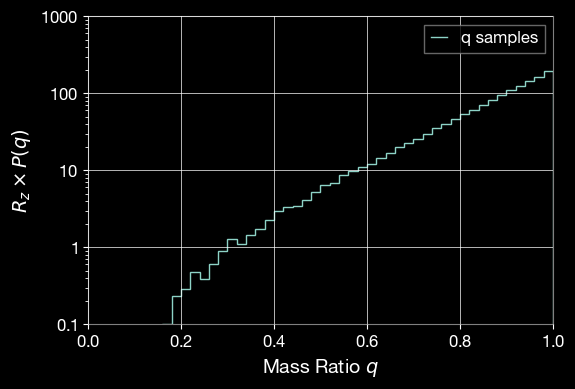

In [11]:
q = m2 / m1
q_bins = np.linspace(0, 1, 51)
q_pdf, q_edges = np.histogram(q, bins=q_bins, density=True)
q_rate = R_z * q_pdf

plt.figure(figsize=(6, 4))
plt.stairs(q_rate, q_edges, label='q samples')
plt.xlabel('Mass Ratio $q$', fontsize=14)
plt.ylabel('$R_z \\times P(q)$', fontsize=14)
plt.yscale('log')
plt.ylim(1e-1, 1e3)
plt.xlim(0, 1)
plt.legend()
plt.show()